In [1]:
import warnings
warnings.simplefilter(action='ignore')

In [2]:
from scipy import stats

import os
if not os.getcwd().endswith('src'):
    os.chdir('../src')
import sys
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from preprocessing_utils import get_drugs_list
from conf import DISEASE, MITH_IN_DRUG, MITH_OUT_DRUG, CS_DIR, \
 TSR_OUT_DRUG,TSR_OUT_DISEASE, TSR_OUT_CSCORE,IMG_DIR, alias_2geneid, cell_line
from loader import load_disease_signature, load_single_drug_signature, load_drug_signatures
from plot_drugs_signatures_correlations import compare_deg_and_mith_genes,  prop_agreeing_signs, print_correlations, plot_correlation, plot_10_most_correlated
print(DISEASE, cell_line)
pert_times=['6h','24h'] 



LIHC HEPG2


# Functions


In [3]:
def top_ranking_drugs(data, cs=-1.95, pval=1, n_best=20):
    '''
    Prints top ranking drugs with given cs and pvalue
    '''
    drugs=data[['disease','drug','connectivity_score','cs_p_value','perturbation_time']][data['connectivity_score']<=cs][data['cs_p_value']<=pval].sort_values(by='connectivity_score')
    print(len(drugs), 'with connectivity score <=',cs,'and P value<=',pval)
    return drugs.head(n_best)

def plot_hist(DEG_cs_data=False, mith_cs_data=False, colname='connectivity_score', pert_times=['6h','24h','6h_24h']):
 
    for pert_time in pert_times:
        if not type(DEG_cs_data)==bool:
            plt.hist(DEG_cs_data[DEG_cs_data.perturbation_time==pert_time][colname], label='DEG', alpha=0.8, bins=100)
            print(DEG_cs_data[DEG_cs_data.perturbation_time==pert_time].shape)
        if not type(mith_cs_data)==bool:
            print(mith_cs_data[mith_cs_data.perturbation_time==pert_time].shape)
            plt.hist(mith_cs_data[mith_cs_data.perturbation_time==pert_time][colname], label='mith', alpha=0.5, bins=100)
        
        plt.grid(linestyle='--')
        plt.xlim(-2,2)
        plt.title(pert_time)
        plt.legend()
        plt.show()

In [33]:
# tanti dei geni significativi per tsr non lo sono per mithril!

# <div align="center"><b>Connectivity scores and drug rankings for LIHC vs HEPG2 cells</b>

## Connectivity scores for  Mith data with hsa2025 base network

In [7]:
CS_OUT=CS_DIR+'output'+os.sep+DISEASE+'_2025'+os.sep
mith_2025_cs_filename='09_12_2025_12_59_mith_connectivity_score.tsv'
mith_2025_cs_data_24=pd.read_csv(CS_DIR+'output'+os.sep+DISEASE+'_2025_24h'+os.sep+mith_2025_cs_filename, sep='\t')
mith_2025_cs_filename='09_12_2025_13_06_mith_connectivity_score.tsv'
mith_2025_cs_data_6=pd.read_csv(CS_DIR+'output'+os.sep+DISEASE+'_2025_6h'+os.sep+mith_2025_cs_filename, sep='\t')
cs_of_pt = {'6h':mith_2025_cs_data_6,'24h':mith_2025_cs_data_24}


### Cortisone rankings

In [8]:
for pert in pert_times:
    
    print('cortisone in data, ', pert,':')
    print(mith_2025_cs_data_24[['drug', 'connectivity_score','cs_p_value', 'perturbation_time']][mith_2025_cs_data_24.perturbation_time==pert][mith_2025_cs_data_24['drug'].str.startswith('cortisone')])

cortisone in data,  6h :
Empty DataFrame
Columns: [drug, connectivity_score, cs_p_value, perturbation_time]
Index: []
cortisone in data,  24h :
Empty DataFrame
Columns: [drug, connectivity_score, cs_p_value, perturbation_time]
Index: []


### Mith 2025 Drug rankings 24h

In [9]:
top_ranking_drugs(mith_2025_cs_data_24, pval=0.01)

0 with connectivity score <= -1.95 and P value<= 0.01


,disease,drug,connectivity_score,cs_p_value,perturbation_time


In [17]:
top_ranking_drugs(mith_2025_cs_data_24)

62 with connectivity score <= -1.95 and P value<= 1


,disease,drug,connectivity_score,cs_p_value,perturbation_time
826,COAD,nabumetone,-1.994946,0.002,24h
432,COAD,CS-1657,-1.993600,0.006,24h
457,COAD,HLI-373,-1.993146,0.004,24h
498,COAD,MK-5108,-1.992058,0.014,24h
851,COAD,ondansetron,-1.991936,0.012,24h
417,COAD,BU-226,-1.991722,0.022,24h
104,COAD,BRD-K03371390,-1.990462,0.024,24h
34,COAD,BAY-K-8644--S-----,-1.989270,0.032,24h
759,COAD,hyoscyamine,-1.989054,0.042,24h
924,COAD,tetrahydrocannabinol-7-oic-aci,-1.989053,0.043,24h


### Mith 2025 Drug rankings 6h

In [11]:
top_ranking_drugs(mith_2025_cs_data_6, pval=0.05)

4 with connectivity score <= -1.95 and P value<= 0.05


,disease,drug,connectivity_score,cs_p_value,perturbation_time
208,LIHC,BRD-A58482795,-1.989202,0.037,6h
2719,LIHC,estradiol-benzoate,-1.988653,0.045,6h
1632,LIHC,FPL-64176,-1.988250,0.045,6h
614,LIHC,BRD-K29500995,-1.987930,0.048,6h


In [17]:
top_ranking_drugs(mith_2025_cs_data_6)

103 with connectivity score <= -1.95 and P value<= 1


,disease,drug,connectivity_score,cs_p_value,perturbation_time
208,LIHC,BRD-A58482795,-1.989202,0.037,6h
2719,LIHC,estradiol-benzoate,-1.988653,0.045,6h
1632,LIHC,FPL-64176,-1.988250,0.045,6h
614,LIHC,BRD-K29500995,-1.987930,0.048,6h
248,LIHC,BRD-A81936046,-1.987186,0.051,6h
253,LIHC,BRD-A83255679,-1.986475,0.075,6h
604,LIHC,BRD-K28377013,-1.986186,0.076,6h
2266,LIHC,VU-0447134-2,-1.986161,0.059,6h
2901,LIHC,larixinic-aci,-1.985944,0.074,6h
3403,LIHC,tosyl-phenylalanyl-chloromethyl-ketone,-1.985496,0.098,6h


## Plot cs distribution: Mith 2025 data

(3507, 10)


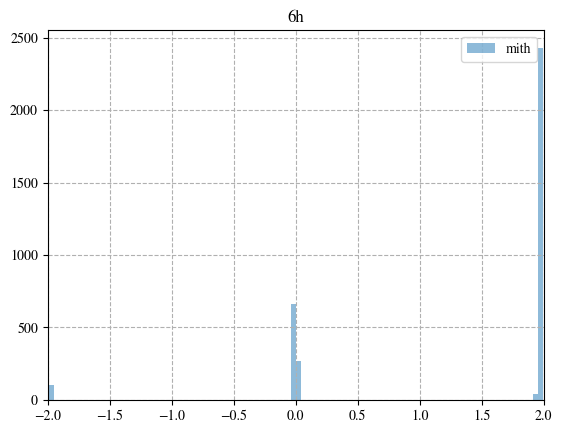

(154, 10)


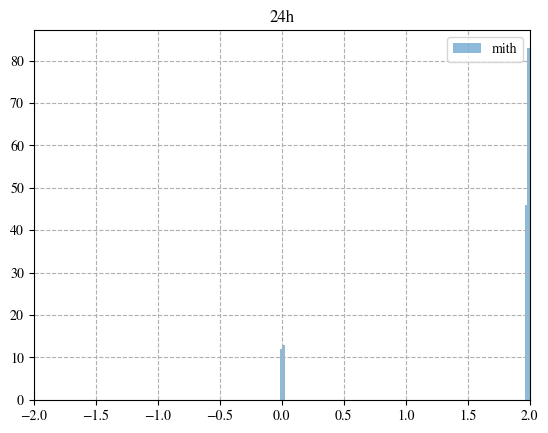

In [25]:
pert_times=['6h','24h'] 
for pert_time in pert_times:
    mith_2025_cs_data=cs_of_pt[pert_time]
    print( mith_2025_cs_data[mith_2025_cs_data.perturbation_time==pert_time].shape)
    plt.hist(mith_2025_cs_data[mith_2025_cs_data.perturbation_time==pert_time]['connectivity_score'], label='mith', alpha=0.5, bins=100)
    
    plt.grid(linestyle='--')
    plt.xlim(-2,2)
    plt.title(pert_time)
    plt.legend()
    plt.show()

Are there values between [0.5,1.5] and [-1.5,-0.5]?

In [82]:
mith_2025_cs_data['connectivity_score'][((mith_2025_cs_data['connectivity_score']<=1.5) & (mith_2025_cs_data['connectivity_score']>=0.5))\
|((mith_2025_cs_data['connectivity_score']>=-1.5) & (mith_2025_cs_data['connectivity_score']<=-0.5))]

Series([], Name: connectivity_score, dtype: float64)

non c'è

# <div align="center"><b>Connectivity scores and drug rankings for COAD vs HET29 cells</b>

In [12]:
DISEASE='COAD'
CS_OUT=CS_DIR+'output'+os.sep+DISEASE+'_2025'+os.sep
mith_2025_cs_filename='09_12_2025_13_22_mith_connectivity_score.tsv'
mith_2025_cs_data_24=pd.read_csv(CS_DIR+'output'+os.sep+DISEASE+'_2025_24h'+os.sep+mith_2025_cs_filename, sep='\t')
mith_2025_cs_filename='09_12_2025_13_29_mith_connectivity_score.tsv'
mith_2025_cs_data_6=pd.read_csv(CS_DIR+'output'+os.sep+DISEASE+'_2025_6h'+os.sep+mith_2025_cs_filename, sep='\t')
cs_of_pt = {'6h':mith_2025_cs_data_6,'24h':mith_2025_cs_data_24}

(4765, 10)


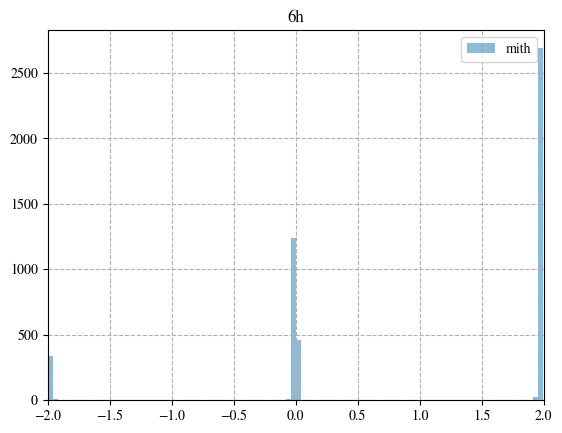

(973, 10)


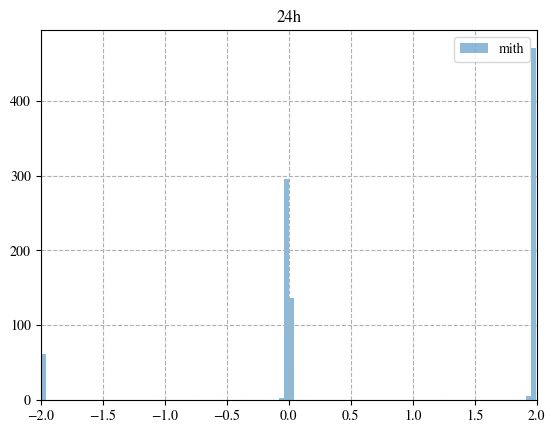

In [13]:
pert_times=['6h','24h'] 
for pert_time in pert_times:
    mith_2025_cs_data=cs_of_pt[pert_time]
    print( mith_2025_cs_data[mith_2025_cs_data.perturbation_time==pert_time].shape)
    plt.hist(mith_2025_cs_data[mith_2025_cs_data.perturbation_time==pert_time]['connectivity_score'], label='mith', alpha=0.5, bins=100)
    
    plt.grid(linestyle='--')
    plt.xlim(-2,2)
    plt.title(pert_time)
    plt.legend()
    plt.show()

In [29]:
for pert in pert_times:
    
    print('cortisone in data, ', pert,':')
    print(mith_2025_cs_data_24[['drug', 'connectivity_score','cs_p_value', 'perturbation_time']][mith_2025_cs_data_24.perturbation_time==pert][mith_2025_cs_data_24['drug'].str.startswith('cortisone')])

cortisone in FC data,  6h :
Empty DataFrame
Columns: [drug, connectivity_score, cs_p_value, perturbation_time]
Index: []
cortisone in FC data,  24h :
          drug  connectivity_score  cs_p_value perturbation_time
659  cortisone            1.986064       0.076               24h


In [18]:
for pert_time in pert_times:
    print('------------------------------',pert_time)
    print(top_ranking_drugs(cs_of_pt[pert_time], pval=0.05))

------------------------------ 6h
71 with connectivity score <= -1.95 and P value<= 0.05
     disease                          drug  connectivity_score  cs_p_value  \
1042    COAD                 BRD-K39829853           -1.996867       0.000   
4494    COAD                    siguazodan           -1.995843       0.002   
1787    COAD                 BRD-K80962769           -1.995458       0.001   
3856    COAD                      imiloxan           -1.995266       0.001   
491     COAD                 BRD-K06186994           -1.995202       0.002   
2170    COAD                     CGP-54626           -1.995073       0.003   
2039    COAD                 BRD-K95138506           -1.994882       0.002   
2457    COAD                    KU-C104123           -1.994818       0.005   
2780    COAD                      RU-24969           -1.994370       0.002   
1456    COAD                 BRD-K63157263           -1.994305       0.006   
3270    COAD  benzyl-quinazolin-4-yl-amine           

# <div align="center"><b>Connectivity scores and drug rankings for BRCA vs MCF7 cells</b>

In [20]:
DISEASE='BRCA'
CS_OUT=CS_DIR+'output'+os.sep+DISEASE+'_2025'+os.sep
mith_2025_cs_filename='09_12_2025_15_44_mith_connectivity_score.tsv'
mith_2025_cs_data_24=pd.read_csv(CS_DIR+'output'+os.sep+DISEASE+'_2025_24h'+os.sep+mith_2025_cs_filename, sep='\t')
mith_2025_cs_filename='09_12_2025_13_30_mith_connectivity_score.tsv'
mith_2025_cs_data_6=pd.read_csv(CS_DIR+'output'+os.sep+DISEASE+'_2025_6h'+os.sep+mith_2025_cs_filename, sep='\t')
cs_of_pt = {'6h':mith_2025_cs_data_6,'24h':mith_2025_cs_data_24}

(4829, 10)


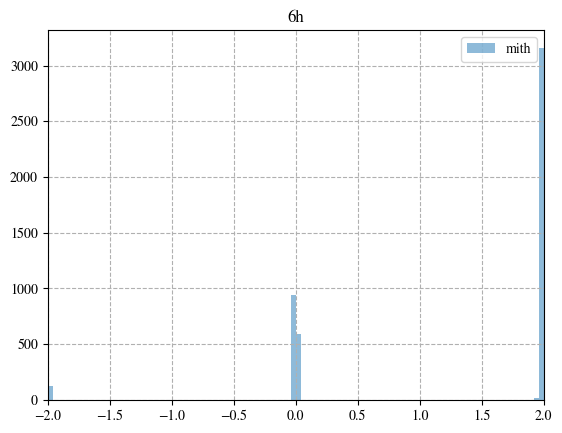

(3265, 10)


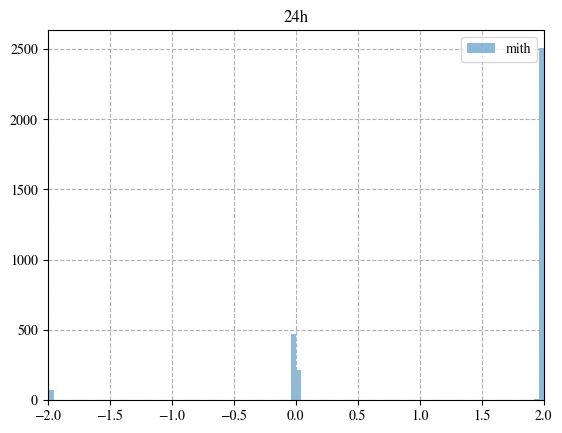

In [34]:
pert_times=['6h','24h'] 
for pert_time in pert_times:
    mith_2025_cs_data=cs_of_pt[pert_time]
    print( mith_2025_cs_data[mith_2025_cs_data.perturbation_time==pert_time].shape)
    plt.hist(mith_2025_cs_data[mith_2025_cs_data.perturbation_time==pert_time]['connectivity_score'], label='mith', alpha=0.5, bins=100)
    
    plt.grid(linestyle='--')
    plt.xlim(-2,2)
    plt.title(pert_time)
    plt.legend()
    plt.show()

In [21]:
for pert_time in pert_times:
    print('------------------------------',pert_time)
    print(top_ranking_drugs(cs_of_pt[pert_time], pval=0.05))

------------------------------ 6h
6 with connectivity score <= -1.95 and P value<= 0.05
     disease           drug  connectivity_score  cs_p_value perturbation_time
277     BRCA  BRD-A54194844           -1.994011       0.004                6h
1339    BRCA  BRD-K56446541           -1.991578       0.030                6h
2120    BRCA  BRD-K98948170           -1.990812       0.030                6h
1340    BRCA  BRD-K56477805           -1.989977       0.039                6h
2528    BRCA     KUC111774N           -1.989660       0.050                6h
1247    BRCA  BRD-K51490254           -1.989336       0.043                6h
------------------------------ 24h
0 with connectivity score <= -1.95 and P value<= 0.05
Empty DataFrame
Columns: [disease, drug, connectivity_score, cs_p_value, perturbation_time]
Index: []
